# 05 — Operational Driver Positioning Recommendations

This notebook translates the final predictive modelling results into practical airport-positioning insights for Yellow Taxi drivers.

The temporal Gradient-Boosted Tree (GBT) was selected as the final model because it achieved the strongest out-of-sample performance on the June 2025 test period. The model uses recurring temporal demand patterns rather than flight-arrival information, since adding scheduled arrivals did not improve the predictive performance of the GBT model.

The objective of this analysis is to identify airport–time combinations associated with relatively high predicted Yellow Taxi pickup demand at JFK and LaGuardia (LGA). These patterns are used to develop practical positioning guidance while recognising that taxi demand alone does not capture driver supply, queue lengths, travel time, or expected fares.

## 1. Load Final Model Predictions

The saved June 2025 out-of-sample predictions from the selected temporal GBT model are loaded from the processed-data directory.

Each observation represents one airport–hour combination and contains both observed Yellow Taxi pickups and the corresponding model prediction.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
    .appName("MAST30034_Project1_DriverRecommendations")
    .getOrCreate()
)

print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/31 20:09:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/31 20:09:11 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/08/31 20:09:11 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/08/31 20:09:11 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


Spark version: 4.2.0


In [2]:
PREDICTIONS_PATH = "../data/processed/final_gbt_predictions.parquet"

predictions = spark.read.parquet(PREDICTIONS_PATH)

print("Prediction rows:", predictions.count())
print("Prediction columns:", predictions.columns)

predictions.groupBy("airport").count().orderBy("airport").show()

Prediction rows: 1440
Prediction columns: ['airport', 'hour', 'hour_of_day', 'day_of_week', 'month', 'taxi_pickups', 'predicted_taxi_pickups']
+-------+-----+
|airport|count|
+-------+-----+
|    JFK|  720|
|    LGA|  720|
+-------+-----+



## 2. Validate Prediction Data

Before constructing operational recommendations, the saved prediction dataset is checked for temporal coverage, missing values, and implausible negative predictions.

In [3]:
predictions.select(
    F.min("hour").alias("min_hour"),
    F.max("hour").alias("max_hour")
).show(truncate=False)

+-------------------+-------------------+
|min_hour           |max_hour           |
+-------------------+-------------------+
|2025-06-01 00:00:00|2025-06-30 23:00:00|
+-------------------+-------------------+



In [4]:
predictions.select(
    F.sum(
        F.col("predicted_taxi_pickups").isNull().cast("int")
    ).alias("missing_predictions"),

    F.sum(
        (F.col("predicted_taxi_pickups") < 0).cast("int")
    ).alias("negative_predictions")
).show()

+-------------------+--------------------+
|missing_predictions|negative_predictions|
+-------------------+--------------------+
|                  0|                   4|
+-------------------+--------------------+



In [5]:
predictions_operational = (
    predictions
    .withColumn(
        "predicted_taxi_pickups",
        F.greatest(
            F.col("predicted_taxi_pickups"),
            F.lit(0.0)
        )
    )
)

predictions_operational.select(
    F.sum(
        (F.col("predicted_taxi_pickups") < 0).cast("int")
    ).alias("negative_predictions_after_clipping")
).show()

+-----------------------------------+
|negative_predictions_after_clipping|
+-----------------------------------+
|                                  0|
+-----------------------------------+



## 3. Define Airport-Specific Demand Thresholds

Taxi pickup volumes differ substantially between JFK and LGA, so a single absolute demand threshold would not provide a comparable measure of unusually high demand across the two airports.

Airport-specific percentiles of predicted demand are therefore used to identify relatively high-demand periods. The 75th percentile represents high predicted demand, while the 90th percentile identifies the most pronounced demand periods within each airport.

In [6]:
demand_thresholds = (
    predictions_operational
    .groupBy("airport")
    .agg(
        F.round(
            F.mean("predicted_taxi_pickups"), 2
        ).alias("mean_predicted_demand"),

        F.round(
            F.expr(
                "percentile_approx(predicted_taxi_pickups, 0.5)"
            ), 2
        ).alias("median_predicted_demand"),

        F.round(
            F.expr(
                "percentile_approx(predicted_taxi_pickups, 0.75)"
            ), 2
        ).alias("p75_predicted_demand"),

        F.round(
            F.expr(
                "percentile_approx(predicted_taxi_pickups, 0.9)"
            ), 2
        ).alias("p90_predicted_demand"),

        F.round(
            F.max("predicted_taxi_pickups"), 2
        ).alias("max_predicted_demand")
    )
    .orderBy("airport")
)

demand_thresholds.show(truncate=False)

+-------+---------------------+-----------------------+--------------------+--------------------+--------------------+
|airport|mean_predicted_demand|median_predicted_demand|p75_predicted_demand|p90_predicted_demand|max_predicted_demand|
+-------+---------------------+-----------------------+--------------------+--------------------+--------------------+
|JFK    |282.35               |241.02                 |426.07              |494.15              |563.57              |
|LGA    |180.1                |221.09                 |273.13              |314.15              |361.23              |
+-------+---------------------+-----------------------+--------------------+--------------------+--------------------+



## 4. Identify High-Demand Airport–Hour Periods

Predicted demand is classified relative to the airport-specific distribution rather than using a common absolute threshold.

Three operational demand categories are defined:

- **Normal demand:** predicted demand below the airport-specific 75th percentile;
- **High demand:** predicted demand from the 75th percentile up to the 90th percentile;
- **Very high demand:** predicted demand at or above the airport-specific 90th percentile.

This relative classification allows high-demand periods to be identified separately for JFK and LGA despite their different overall pickup volumes.

In [7]:
recommendation_data = (
    predictions_operational
    .join(
        demand_thresholds.select(
            "airport",
            "p75_predicted_demand",
            "p90_predicted_demand"
        ),
        on="airport",
        how="left"
    )
    .withColumn(
        "demand_level",
        F.when(
            F.col("predicted_taxi_pickups")
            >= F.col("p90_predicted_demand"),
            "Very High"
        )
        .when(
            F.col("predicted_taxi_pickups")
            >= F.col("p75_predicted_demand"),
            "High"
        )
        .otherwise("Normal")
    )
)

recommendation_data.select(
    "airport",
    "hour",
    "predicted_taxi_pickups",
    "demand_level"
).show(20, truncate=False)

+-------+-------------------+----------------------+------------+
|airport|hour               |predicted_taxi_pickups|demand_level|
+-------+-------------------+----------------------+------------+
|JFK    |2025-06-01 00:00:00|193.92641612010152    |Normal      |
|JFK    |2025-06-01 01:00:00|130.5347830955028     |Normal      |
|JFK    |2025-06-01 02:00:00|45.95674512471611     |Normal      |
|JFK    |2025-06-01 03:00:00|23.29602537818731     |Normal      |
|JFK    |2025-06-01 04:00:00|19.049951149667642    |Normal      |
|JFK    |2025-06-01 05:00:00|78.7358649071004      |Normal      |
|JFK    |2025-06-01 06:00:00|169.1126370096119     |Normal      |
|JFK    |2025-06-01 07:00:00|189.9001653857359     |Normal      |
|JFK    |2025-06-01 08:00:00|151.54613179547056    |Normal      |
|JFK    |2025-06-01 09:00:00|147.6856868965722     |Normal      |
|JFK    |2025-06-01 10:00:00|184.92826941224683    |Normal      |
|JFK    |2025-06-01 11:00:00|205.74377558281188    |Normal      |
|JFK    |2

In [8]:
demand_level_summary = (
    recommendation_data
    .groupBy(
        "airport",
        "demand_level"
    )
    .count()
    .orderBy(
        "airport",
        "demand_level"
    )
)

demand_level_summary.show(truncate=False)

+-------+------------+-----+
|airport|demand_level|count|
+-------+------------+-----+
|JFK    |High        |110  |
|JFK    |Normal      |540  |
|JFK    |Very High   |70   |
|LGA    |High        |108  |
|LGA    |Normal      |541  |
|LGA    |Very High   |71   |
+-------+------------+-----+



In [9]:
hourly_positioning_summary = (
    recommendation_data
    .withColumn(
        "is_high_demand",
        F.when(
            F.col("demand_level").isin("High", "Very High"),
            1
        ).otherwise(0)
    )
    .withColumn(
        "is_very_high_demand",
        F.when(
            F.col("demand_level") == "Very High",
            1
        ).otherwise(0)
    )
    .groupBy(
        "airport",
        "hour_of_day"
    )
    .agg(
        F.round(
            F.mean("predicted_taxi_pickups"), 2
        ).alias("mean_predicted_demand"),

        F.round(
            F.mean("taxi_pickups"), 2
        ).alias("mean_observed_demand"),

        F.round(
            F.mean("is_high_demand") * 100, 1
        ).alias("high_demand_rate_pct"),

        F.round(
            F.mean("is_very_high_demand") * 100, 1
        ).alias("very_high_demand_rate_pct")
    )
    .orderBy(
        "airport",
        "hour_of_day"
    )
)

hourly_positioning_summary.show(48, truncate=False)

+-------+-----------+---------------------+--------------------+--------------------+-------------------------+
|airport|hour_of_day|mean_predicted_demand|mean_observed_demand|high_demand_rate_pct|very_high_demand_rate_pct|
+-------+-----------+---------------------+--------------------+--------------------+-------------------------+
|JFK    |0          |282.7                |355.97              |0.0                 |0.0                      |
|JFK    |1          |170.92               |214.07              |0.0                 |0.0                      |
|JFK    |2          |55.47                |68.93               |0.0                 |0.0                      |
|JFK    |3          |29.95                |29.97               |0.0                 |0.0                      |
|JFK    |4          |27.08                |22.07               |0.0                 |0.0                      |
|JFK    |5          |90.59                |79.93               |0.0                 |0.0                

## 5. Construct Operational Positioning Profiles

The airport-hour summaries are now ranked according to the frequency with which each hour is classified as high or very high demand during the June 2025 test period.

High-demand frequency is used as the primary operational criterion because it reflects the consistency of elevated predicted demand across days. Mean predicted demand is retained as a secondary measure to distinguish between hours with similar high-demand frequencies.

The ranking is descriptive rather than prescriptive: it identifies recurring demand opportunities but does not account for taxi supply, queue lengths, traffic conditions, or expected fares.

In [10]:
ranked_positioning_hours = (
    hourly_positioning_summary
    .orderBy(
        "airport",
        F.desc("high_demand_rate_pct"),
        F.desc("very_high_demand_rate_pct"),
        F.desc("mean_predicted_demand")
    )
)

ranked_positioning_hours.show(48, truncate=False)

+-------+-----------+---------------------+--------------------+--------------------+-------------------------+
|airport|hour_of_day|mean_predicted_demand|mean_observed_demand|high_demand_rate_pct|very_high_demand_rate_pct|
+-------+-----------+---------------------+--------------------+--------------------+-------------------------+
|JFK    |16         |505.97               |465.57              |100.0               |33.3                     |
|JFK    |17         |479.03               |445.2               |100.0               |33.3                     |
|JFK    |15         |471.83               |419.57              |100.0               |33.3                     |
|JFK    |20         |463.91               |410.67              |73.3                |33.3                     |
|JFK    |22         |456.68               |404.17              |46.7                |33.3                     |
|JFK    |21         |447.27               |400.63              |46.7                |16.7               

In [11]:
from pyspark.sql.window import Window

positioning_rank_window = (
    Window
    .partitionBy("airport")
    .orderBy(
        F.desc("high_demand_rate_pct"),
        F.desc("very_high_demand_rate_pct"),
        F.desc("mean_predicted_demand")
    )
)

top_positioning_hours = (
    hourly_positioning_summary
    .withColumn(
        "positioning_rank",
        F.row_number().over(positioning_rank_window)
    )
    .filter(F.col("positioning_rank") <= 8)
    .orderBy("airport", "positioning_rank")
)

top_positioning_hours.show(16, truncate=False)

+-------+-----------+---------------------+--------------------+--------------------+-------------------------+----------------+
|airport|hour_of_day|mean_predicted_demand|mean_observed_demand|high_demand_rate_pct|very_high_demand_rate_pct|positioning_rank|
+-------+-----------+---------------------+--------------------+--------------------+-------------------------+----------------+
|JFK    |16         |505.97               |465.57              |100.0               |33.3                     |1               |
|JFK    |17         |479.03               |445.2               |100.0               |33.3                     |2               |
|JFK    |15         |471.83               |419.57              |100.0               |33.3                     |3               |
|JFK    |20         |463.91               |410.67              |73.3                |33.3                     |4               |
|JFK    |22         |456.68               |404.17              |46.7                |33.3        

In [12]:
recommendation_by_day_type = (
    recommendation_data
    .withColumn(
        "day_type",
        F.when(
            F.col("day_of_week").isin(1, 7),
            "Weekend"
        ).otherwise("Weekday")
    )
    .withColumn(
        "is_high_demand",
        F.when(
            F.col("demand_level").isin("High", "Very High"),
            1
        ).otherwise(0)
    )
    .withColumn(
        "is_very_high_demand",
        F.when(
            F.col("demand_level") == "Very High",
            1
        ).otherwise(0)
    )
)

In [13]:
day_type_positioning_summary = (
    recommendation_by_day_type
    .groupBy(
        "airport",
        "day_type",
        "hour_of_day"
    )
    .agg(
        F.round(
            F.mean("predicted_taxi_pickups"), 2
        ).alias("mean_predicted_demand"),

        F.round(
            F.mean("taxi_pickups"), 2
        ).alias("mean_observed_demand"),

        F.round(
            F.mean("is_high_demand") * 100, 1
        ).alias("high_demand_rate_pct"),

        F.round(
            F.mean("is_very_high_demand") * 100, 1
        ).alias("very_high_demand_rate_pct")
    )
    .orderBy(
        "airport",
        "day_type",
        "hour_of_day"
    )
)

day_type_positioning_summary.show(96, truncate=False)

+-------+--------+-----------+---------------------+--------------------+--------------------+-------------------------+
|airport|day_type|hour_of_day|mean_predicted_demand|mean_observed_demand|high_demand_rate_pct|very_high_demand_rate_pct|
+-------+--------+-----------+---------------------+--------------------+--------------------+-------------------------+
|JFK    |Weekday |0          |314.69               |382.33              |0.0                 |0.0                      |
|JFK    |Weekday |1          |184.59               |238.48              |0.0                 |0.0                      |
|JFK    |Weekday |2          |58.18                |71.29               |0.0                 |0.0                      |
|JFK    |Weekday |3          |31.48                |27.62               |0.0                 |0.0                      |
|JFK    |Weekday |4          |29.73                |21.57               |0.0                 |0.0                      |
|JFK    |Weekday |5          |96

In [14]:
day_type_rank_window = (
    Window
    .partitionBy("airport", "day_type")
    .orderBy(
        F.desc("high_demand_rate_pct"),
        F.desc("very_high_demand_rate_pct"),
        F.desc("mean_predicted_demand")
    )
)

top_day_type_hours = (
    day_type_positioning_summary
    .withColumn(
        "positioning_rank",
        F.row_number().over(day_type_rank_window)
    )
    .filter(F.col("positioning_rank") <= 5)
    .orderBy(
        "airport",
        "day_type",
        "positioning_rank"
    )
)

top_day_type_hours.show(20, truncate=False)

+-------+--------+-----------+---------------------+--------------------+--------------------+-------------------------+----------------+
|airport|day_type|hour_of_day|mean_predicted_demand|mean_observed_demand|high_demand_rate_pct|very_high_demand_rate_pct|positioning_rank|
+-------+--------+-----------+---------------------+--------------------+--------------------+-------------------------+----------------+
|JFK    |Weekday |16         |503.82               |446.0               |100.0               |23.8                     |1               |
|JFK    |Weekday |17         |478.33               |431.33              |100.0               |23.8                     |2               |
|JFK    |Weekday |15         |466.51               |393.24              |100.0               |23.8                     |3               |
|JFK    |Weekday |20         |456.48               |395.24              |81.0                |23.8                     |4               |
|JFK    |Weekday |22         |437.

## 6. Translate Predicted Demand into Driver Positioning Guidance

Predicted airport-hour demand is translated into simple operational positioning guidance using the airport-specific demand classifications defined above.

Very-high-demand periods receive the strongest positioning priority, while high-demand periods indicate elevated positioning opportunities. Normal-demand periods are treated as routine conditions without a special demand-based positioning signal.

These recommendations describe predicted passenger pickup opportunities rather than expected driver profitability, since taxi supply, queue lengths, traffic conditions, fares, and repositioning costs are not observed in the available data.

In [15]:
driver_recommendations = (
    recommendation_data
    .withColumn(
        "positioning_guidance",
        F.when(
            F.col("demand_level") == "Very High",
            "Strongly prioritise"
        )
        .when(
            F.col("demand_level") == "High",
            "Prioritise"
        )
        .otherwise(
            "Routine"
        )
    )
)

driver_recommendations.select(
    "airport",
    "hour",
    "predicted_taxi_pickups",
    "demand_level",
    "positioning_guidance"
).orderBy(
    "airport",
    "hour"
).show(20, truncate=False)

+-------+-------------------+----------------------+------------+--------------------+
|airport|hour               |predicted_taxi_pickups|demand_level|positioning_guidance|
+-------+-------------------+----------------------+------------+--------------------+
|JFK    |2025-06-01 00:00:00|193.92641612010152    |Normal      |Routine             |
|JFK    |2025-06-01 01:00:00|130.5347830955028     |Normal      |Routine             |
|JFK    |2025-06-01 02:00:00|45.95674512471611     |Normal      |Routine             |
|JFK    |2025-06-01 03:00:00|23.29602537818731     |Normal      |Routine             |
|JFK    |2025-06-01 04:00:00|19.049951149667642    |Normal      |Routine             |
|JFK    |2025-06-01 05:00:00|78.7358649071004      |Normal      |Routine             |
|JFK    |2025-06-01 06:00:00|169.1126370096119     |Normal      |Routine             |
|JFK    |2025-06-01 07:00:00|189.9001653857359     |Normal      |Routine             |
|JFK    |2025-06-01 08:00:00|151.5461317954

In [16]:
operational_profile = (
    hourly_positioning_summary
    .withColumn(
        "positioning_priority",
        F.when(
            F.col("very_high_demand_rate_pct") >= 50,
            "Very High"
        )
        .when(
            F.col("high_demand_rate_pct") >= 50,
            "High"
        )
        .otherwise(
            "Normal"
        )
    )
    .orderBy(
        "airport",
        "hour_of_day"
    )
)

operational_profile.show(48, truncate=False)

+-------+-----------+---------------------+--------------------+--------------------+-------------------------+--------------------+
|airport|hour_of_day|mean_predicted_demand|mean_observed_demand|high_demand_rate_pct|very_high_demand_rate_pct|positioning_priority|
+-------+-----------+---------------------+--------------------+--------------------+-------------------------+--------------------+
|JFK    |0          |282.7                |355.97              |0.0                 |0.0                      |Normal              |
|JFK    |1          |170.92               |214.07              |0.0                 |0.0                      |Normal              |
|JFK    |2          |55.47                |68.93               |0.0                 |0.0                      |Normal              |
|JFK    |3          |29.95                |29.97               |0.0                 |0.0                      |Normal              |
|JFK    |4          |27.08                |22.07               |0.0  

In [17]:
# Convert the compact operational profile to pandas for plotting
operational_profile_pd = operational_profile.toPandas()

operational_profile_pd.head()

,airport,hour_of_day,mean_predicted_demand,mean_observed_demand,high_demand_rate_pct,very_high_demand_rate_pct,positioning_priority
0,JFK,0,282.70,355.97,0.0,0.0,Normal
1,JFK,1,170.92,214.07,0.0,0.0,Normal
2,JFK,2,55.47,68.93,0.0,0.0,Normal
3,JFK,3,29.95,29.97,0.0,0.0,Normal
4,JFK,4,27.08,22.07,0.0,0.0,Normal


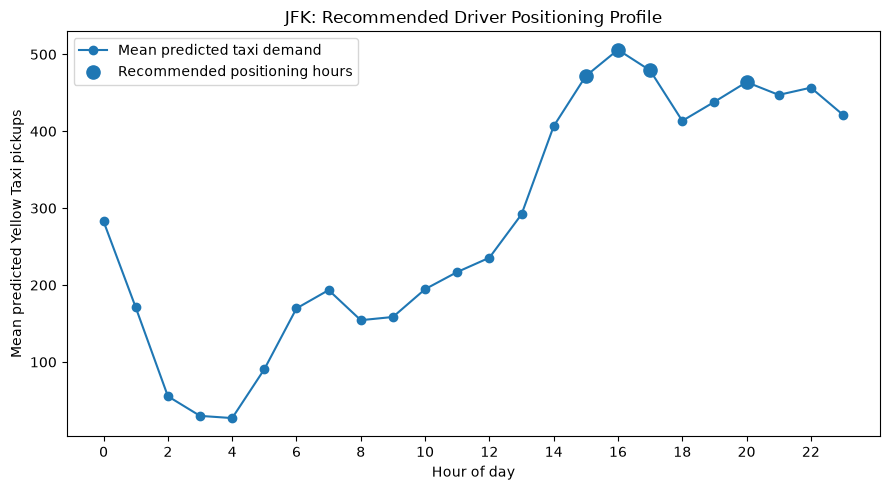

In [18]:
# Plot the operational positioning profile for JFK
jfk_profile = operational_profile_pd[
    operational_profile_pd["airport"] == "JFK"
].sort_values("hour_of_day")

plt.figure(figsize=(9, 5))

plt.plot(
    jfk_profile["hour_of_day"],
    jfk_profile["mean_predicted_demand"],
    marker="o",
    label="Mean predicted taxi demand"
)

# Highlight hours classified as High or Very High
priority_hours = jfk_profile[
    jfk_profile["positioning_priority"].isin(["High", "Very High"])
]

plt.scatter(
    priority_hours["hour_of_day"],
    priority_hours["mean_predicted_demand"],
    s=90,
    label="Recommended positioning hours"
)

plt.xlabel("Hour of day")
plt.ylabel("Mean predicted Yellow Taxi pickups")
plt.title("JFK: Recommended Driver Positioning Profile")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.tight_layout()

plt.show()

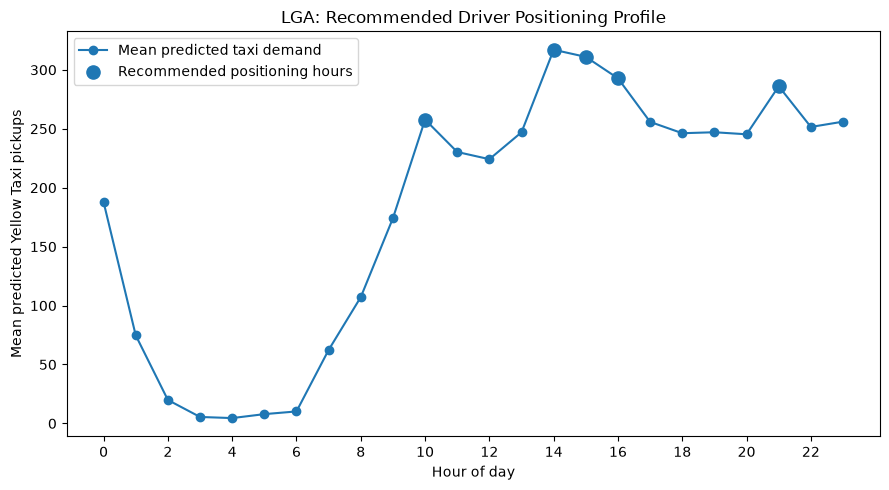

In [19]:
# Plot the operational positioning profile for LGA
lga_profile = operational_profile_pd[
    operational_profile_pd["airport"] == "LGA"
].sort_values("hour_of_day")

plt.figure(figsize=(9, 5))

plt.plot(
    lga_profile["hour_of_day"],
    lga_profile["mean_predicted_demand"],
    marker="o",
    label="Mean predicted taxi demand"
)

# Highlight hours classified as High or Very High
priority_hours = lga_profile[
    lga_profile["positioning_priority"].isin(["High", "Very High"])
]

plt.scatter(
    priority_hours["hour_of_day"],
    priority_hours["mean_predicted_demand"],
    s=90,
    label="Recommended positioning hours"
)

plt.xlabel("Hour of day")
plt.ylabel("Mean predicted Yellow Taxi pickups")
plt.title("LGA: Recommended Driver Positioning Profile")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.tight_layout()

plt.show()

## 7. Compare Operational Positioning Profiles

The airport-specific positioning profiles are compared to identify when predicted Yellow Taxi demand is sufficiently high and persistent to justify prioritising an airport.

Recommended positioning hours are determined from the previously defined demand thresholds and consistency rules rather than manually selected time periods. This provides an interpretable operational summary of when drivers may benefit from positioning near JFK or LGA.

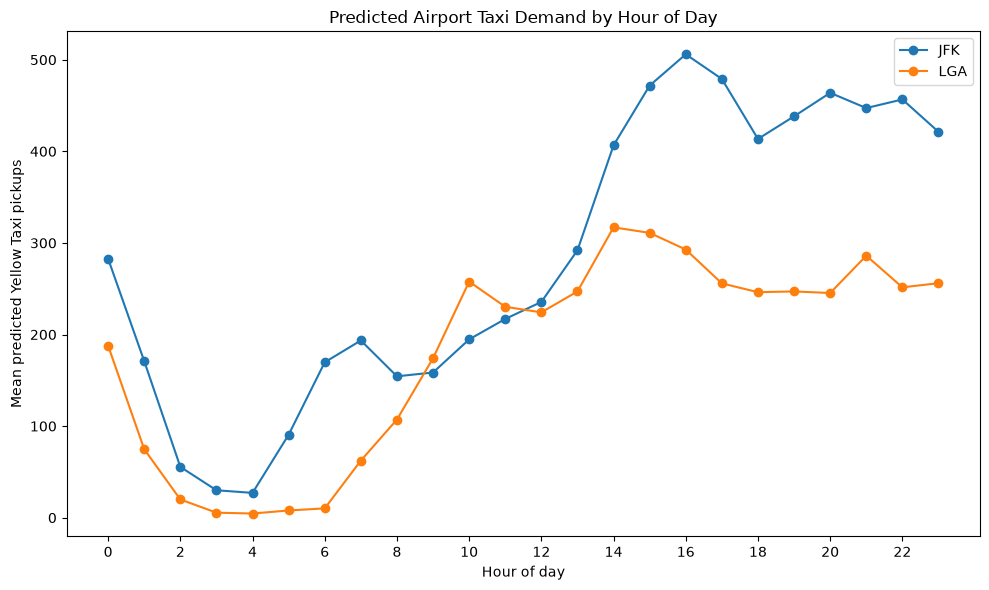

In [28]:
# Compare mean predicted taxi demand across JFK and LGA
comparison_pd = operational_profile_pd.sort_values(
    ["airport", "hour_of_day"]
)

plt.figure(figsize=(10, 6))

for airport in ["JFK", "LGA"]:
    airport_data = comparison_pd[
        comparison_pd["airport"] == airport
    ]

    plt.plot(
        airport_data["hour_of_day"],
        airport_data["mean_predicted_demand"],
        marker="o",
        label=airport
    )

plt.xlabel("Hour of day")
plt.ylabel("Mean predicted Yellow Taxi pickups")
plt.title("Predicted Airport Taxi Demand by Hour of Day")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.tight_layout()
plt.savefig(
    "../plots/predicted_demand_by_airport.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Convert positioning priority into an operational score
priority_score_pd = operational_profile_pd.copy()

priority_score_pd["priority_score"] = (
    priority_score_pd["positioning_priority"]
    .map({
        "Normal": 0,
        "High": 1
    })
)

priority_score_pd[
    [
        "airport",
        "hour_of_day",
        "mean_predicted_demand",
        "positioning_priority",
        "priority_score"
    ]
].head()

,airport,hour_of_day,mean_predicted_demand,positioning_priority,priority_score
0,JFK,0,282.70,Normal,0.0
1,JFK,1,170.92,Normal,0.0
2,JFK,2,55.47,Normal,0.0
3,JFK,3,29.95,Normal,0.0
4,JFK,4,27.08,Normal,0.0


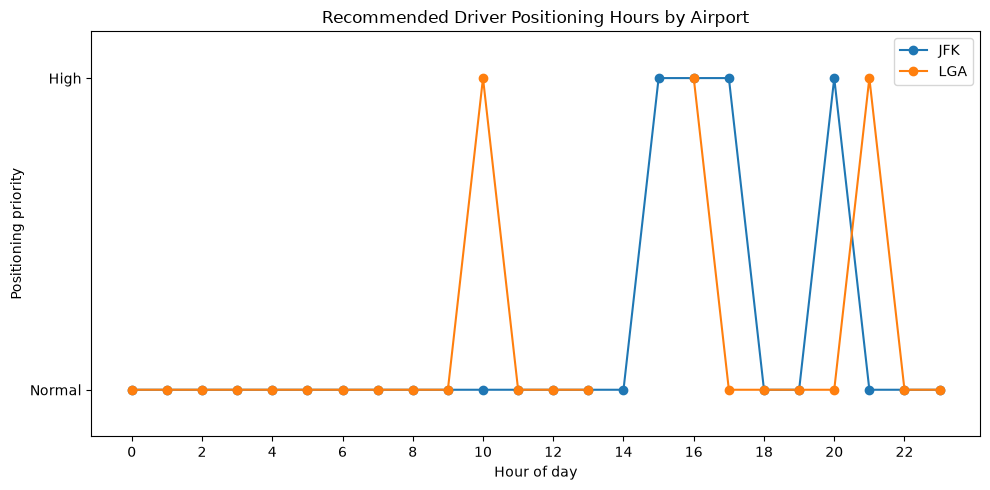

In [29]:
# Plot airport positioning priorities by hour
plt.figure(figsize=(10, 5))

for airport in ["JFK", "LGA"]:
    airport_data = priority_score_pd[
        priority_score_pd["airport"] == airport
    ].sort_values("hour_of_day")

    plt.plot(
        airport_data["hour_of_day"],
        airport_data["priority_score"],
        marker="o",
        label=airport
    )

plt.xlabel("Hour of day")
plt.ylabel("Positioning priority")
plt.title("Recommended Driver Positioning Hours by Airport")
plt.xticks(range(0, 24, 2))
plt.yticks(
    [0, 1],
    ["Normal", "High"]
)
plt.ylim(-0.15, 1.15)
plt.legend()
plt.tight_layout()
plt.savefig(
    "../plots/recommended_positioning_hours_by_airport.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Weekday and Weekend Positioning Recommendations

Airport taxi demand varies not only by hour of day but also between weekdays and weekends. To provide more operationally useful guidance, positioning profiles are therefore examined separately by day type.

The following summaries use the model-based demand estimates together with the previously defined airport-specific demand thresholds. This allows recommended positioning periods to reflect both the airport and the type of day.

In [23]:
# Rank positioning hours separately by airport and day type
day_type_rank_window = Window.partitionBy(
    "airport",
    "day_type"
).orderBy(
    F.desc("high_demand_rate_pct"),
    F.desc("very_high_demand_rate_pct"),
    F.desc("mean_predicted_demand")
)

top_day_type_positioning = (
    day_type_positioning_summary
    .withColumn(
        "positioning_rank",
        F.row_number().over(day_type_rank_window)
    )
    .filter(F.col("positioning_rank") <= 5)
    .orderBy(
        "airport",
        "day_type",
        "positioning_rank"
    )
)

top_day_type_positioning.show(20, truncate=False)

+-------+--------+-----------+---------------------+--------------------+--------------------+-------------------------+----------------+
|airport|day_type|hour_of_day|mean_predicted_demand|mean_observed_demand|high_demand_rate_pct|very_high_demand_rate_pct|positioning_rank|
+-------+--------+-----------+---------------------+--------------------+--------------------+-------------------------+----------------+
|JFK    |Weekday |16         |503.82               |446.0               |100.0               |23.8                     |1               |
|JFK    |Weekday |17         |478.33               |431.33              |100.0               |23.8                     |2               |
|JFK    |Weekday |15         |466.51               |393.24              |100.0               |23.8                     |3               |
|JFK    |Weekday |20         |456.48               |395.24              |81.0                |23.8                     |4               |
|JFK    |Weekday |22         |437.

In [24]:
# Convert the aggregated airport-day-type-hour summary to pandas
day_type_positioning_pd = (
    day_type_positioning_summary
    .orderBy("airport", "day_type", "hour_of_day")
    .toPandas()
)

day_type_positioning_pd.head()

,airport,day_type,hour_of_day,mean_predicted_demand,mean_observed_demand,high_demand_rate_pct,very_high_demand_rate_pct
0,JFK,Weekday,0,314.69,382.33,0.0,0.0
1,JFK,Weekday,1,184.59,238.48,0.0,0.0
2,JFK,Weekday,2,58.18,71.29,0.0,0.0
3,JFK,Weekday,3,31.48,27.62,0.0,0.0
4,JFK,Weekday,4,29.73,21.57,0.0,0.0


In [25]:
# Construct a matrix of mean predicted taxi demand
heatmap_data = (
    day_type_positioning_pd
    .assign(
        airport_day_type=
        day_type_positioning_pd["airport"]
        + " "
        + day_type_positioning_pd["day_type"]
    )
    .pivot(
        index="airport_day_type",
        columns="hour_of_day",
        values="mean_predicted_demand"
    )
)

heatmap_data = heatmap_data.reindex([
    "JFK Weekday",
    "JFK Weekend",
    "LGA Weekday",
    "LGA Weekend"
])

heatmap_data

hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
airport_day_type,,,,,,,,,,,,,,,,,,,,,
JFK Weekday,314.69,184.59,58.18,31.48,29.73,96.04,173.73,199.36,158.47,167.28,...,404.35,466.51,503.82,478.33,406.06,431.58,456.48,432.45,437.83,402.41
JFK Weekend,208.05,139.02,49.15,26.38,20.89,77.87,160.31,179.84,144.75,138.09,...,411.79,484.24,511.00,480.67,430.93,453.81,481.24,481.86,500.68,465.47
LGA Weekday,222.19,89.97,21.94,4.49,4.71,10.54,10.22,74.86,130.67,203.79,...,336.30,332.49,309.89,263.83,257.15,258.54,259.20,298.74,258.62,265.31
LGA Weekend,107.42,39.14,15.11,7.84,4.14,1.71,10.09,33.17,52.35,104.93,...,272.09,260.81,252.93,237.18,220.72,220.26,212.93,256.48,235.02,234.37


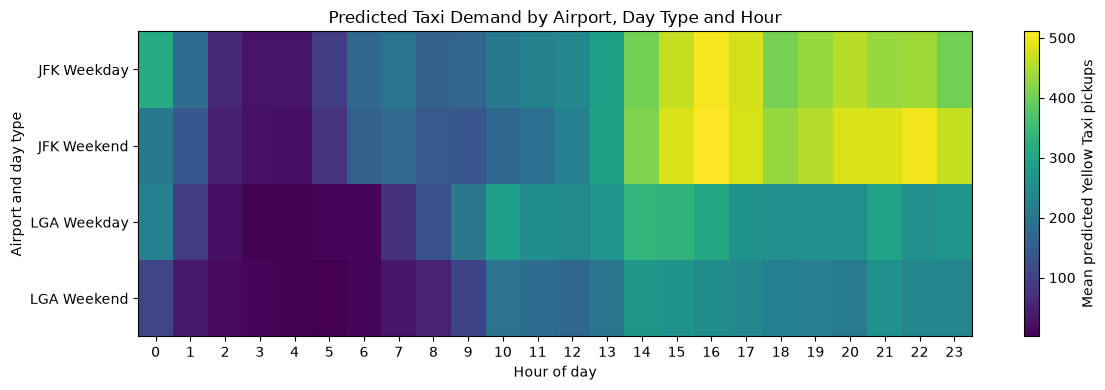

In [30]:
# Plot airport and day-type positioning heatmap
fig, ax = plt.subplots(figsize=(12, 4))

heatmap = ax.imshow(
    heatmap_data.values,
    aspect="auto"
)

ax.set_xticks(range(24))
ax.set_xticklabels(range(24))

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Airport and day type")
ax.set_title(
    "Predicted Taxi Demand by Airport, Day Type and Hour"
)

fig.colorbar(
    heatmap,
    ax=ax,
    label="Mean predicted Yellow Taxi pickups"
)

plt.tight_layout()
fig.savefig(
    "../plots/predicted_demand_heatmap_by_day_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Final Operational Recommendations

The operational analysis identifies distinct driver-positioning patterns for JFK and LGA. Recommendations are based on out-of-sample taxi-demand predictions for June 2025 and should therefore be interpreted as evidence-based positioning guidance for the study period rather than as universal operating rules.

At JFK, the strongest and most consistent positioning opportunity occurs during the mid-afternoon and early evening. In particular, 15:00–17:00 repeatedly ranks among the highest-demand periods on both weekdays and weekends. Elevated predicted demand also persists later into the evening, especially on weekends.

At LGA, the principal positioning window occurs somewhat earlier, with 14:00–16:00 emerging as the most important period. Weekend patterns additionally indicate relatively stronger positioning opportunities during the late evening.

These findings suggest that a single airport-wide positioning rule would be inappropriate. Drivers could instead use airport- and time-specific demand profiles, with additional distinction between weekdays and weekends, to identify periods in which positioning near JFK or LGA is more likely to coincide with elevated Yellow Taxi pickup demand.

The recommendations should nevertheless be interpreted cautiously. Predicted taxi demand does not directly measure driver profitability, passenger waiting time, taxi supply, queue length, traffic conditions, or the opportunity cost of travelling to an airport. The positioning profiles therefore identify demand opportunities rather than guaranteed profitable driving strategies.

In [27]:
# Final summary of recommended positioning hours
final_recommendations = (
    top_day_type_positioning
    .select(
        "airport",
        "day_type",
        "positioning_rank",
        "hour_of_day",
        "mean_predicted_demand",
        "high_demand_rate_pct"
    )
    .orderBy(
        "airport",
        "day_type",
        "positioning_rank"
    )
)

final_recommendations.show(20, truncate=False)

+-------+--------+----------------+-----------+---------------------+--------------------+
|airport|day_type|positioning_rank|hour_of_day|mean_predicted_demand|high_demand_rate_pct|
+-------+--------+----------------+-----------+---------------------+--------------------+
|JFK    |Weekday |1               |16         |503.82               |100.0               |
|JFK    |Weekday |2               |17         |478.33               |100.0               |
|JFK    |Weekday |3               |15         |466.51               |100.0               |
|JFK    |Weekday |4               |20         |456.48               |81.0                |
|JFK    |Weekday |5               |22         |437.83               |42.9                |
|JFK    |Weekend |1               |16         |511.0                |100.0               |
|JFK    |Weekend |2               |15         |484.24               |100.0               |
|JFK    |Weekend |3               |17         |480.67               |100.0               |